# **Importing the required libraries and getting the data ready** **$\alpha$** 

In [20]:
import csv
import numpy as np
import kagglehub
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import precision_score, recall_score,confusion_matrix, precision_recall_curve
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import average_precision_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import email
from email.header import decode_header
import imaplib
from kaggle_secrets import UserSecretsClient

df = pd.read_csv("/kaggle/input/datasets/ouicifarouk/meajor/meajor_cleaned_preprocessed.csv", na_values=["nan","Nan"])
df["has_attachments"] = df["has_attachments"].astype(int)
df = df.dropna(subset=["label","url_count","subject"])
df["label"] = pd.to_numeric(df["label"],errors="coerce")

df["subject"] = df["subject"].fillna("") # we fill any missing text with empty text
df["body"] = df["body"].fillna("")
df= df[df["label"].isin([0,1])]

df["text"] = df["subject"] + " " + df["body"] # combining the subject and the body of the email into one column
df_ready = df[["text","label","has_attachments","url_count","urls"]].copy() 
df_ready["urls"] = np.where(df_ready["url_count"] == 0,"No URL",df["urls"])
df_ready = df_ready.sample(frac=1, random_state=42).reset_index(drop=True)
start_row = int(len(df_ready) * 0.9)
df_val = df_ready.iloc[start_row:] # here we cut the last 10% of the data as holdout set
df_ready = df_ready.iloc[:start_row] # here we delete the 10% we cut from the training/test data
X_text = df_ready.drop("label",axis=1)
y = df_ready["label"].astype(int) 


X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)


# **Pipelines preparing and model training with special functions** **$\gamma$**

In [21]:
standard_transformer = Pipeline([
    ("scaler",StandardScaler()),
])

preprocess = ColumnTransformer([
    ("TF-IDF_text",TfidfVectorizer(stop_words="english",max_features=25000,ngram_range=(1, 2)),"text"),
    ("TF-IDF_urls",TfidfVectorizer(stop_words="english",max_features=1000,ngram_range=(1, 2)),"urls"),
    ("Scaler",standard_transformer,["url_count"]),
    ("pass_binary", "passthrough", ["has_attachments"]), # This one passing the 'text' column into the first step the the 'urls' one into the second 
     ]) # We pass here 'passthrough' for the 'has_attachments' column because we have nothing to do for and we don't want the ColumnTransformer to delete it

The cross validation is : [0 0 0 ... 0 0 0]
confusion matrix is : 
 [[10234   564]
 [ 1401  7103]]
Precision: 0.9264
Recall: 0.8353
Train Precision: 0.9250
F1 Score : 0.8785


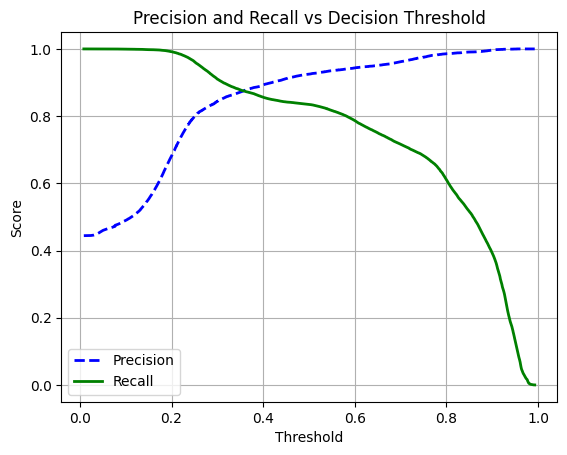

Best thershold is 0.49581621869927134
Max F1-Score: 0.8779
Corresponding Precision: 0.9244, Recall: 0.8360


In [23]:
model = Pipeline([
    ("preprocessor",preprocess),
    ("log_model",SGDClassifier(loss="log_loss",penalty="elasticnet",alpha=0.001,n_jobs=-1,random_state=42)),
]) # This pipeline contains the ColumnTransformer and the model

def pipeline_wrapper(pipeline,X_btch,y_btch,classes=None): # This function is specialized on training the model with the pipeline bt partial training
    X_transformed = X_btch
    for name,step in pipeline.steps[:-1]:
        X_transformed = step.transform(X_transformed)
    last_step  = pipeline.steps[-1][1]
    if classes is not None:
        last_step.partial_fit(X_transformed,y_btch,classes=classes)
    else:
        last_step.partial_fit(X_transformed,y_btch)
    return pipeline 

model.named_steps["preprocessor"].fit(X_train_text) # Building the TF-IDF vocabulary for the model
batch_size = 10000 # Number of batches for the partial training 
classes = np.unique(y_train)
n_samples = X_train_text.shape[0]

for start_idx in range(0, n_samples, batch_size): # This for loop do the work of training the model by batches
    end_idx = min(start_idx + batch_size, n_samples)
    X_batch = X_train_text[start_idx:end_idx]
    y_batch = y_train.iloc[start_idx:end_idx]
    pipeline_wrapper(model,X_batch,y_batch,classes=classes)
y_train_pred = model.predict(X_train_text)
y_pred = model.predict(X_test_text)

cross = cross_val_predict(model,X_train_text,y_train,cv=5,n_jobs=-1) # Using the cross validation to get the model predictions on training
confusion = confusion_matrix(y_test,y_pred)
print(f"The cross validation is : {cross}")
print(f"confusion matrix is : \n {confusion}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Train Precision: {precision_score(y_train, y_train_pred):.4f}")
f1 = f1_score(y_test,y_pred)
y_scores = model.predict_proba(X_train_text)[:,1] # Here we get the positive class out of the model prediction probability to use it to find the best threshold
pr, rc, thresholds = precision_recall_curve(y_train,y_scores)
print(f"F1 Score : {(f1):.4f}")
# This part is to plotting the PR curve
import matplotlib.pyplot as plt
plt.plot(thresholds, pr[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, rc[:-1], 'g-', label='Recall', linewidth=2)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Decision Threshold')
plt.grid(True)
plt.legend(loc='best')
plt.show()

f1_scores = 2 * (pr * rc) / (pr + rc + 1e-10) # Calculate the F1 scores for every precision and recall
idx = np.argmax(f1_scores[:-1]) # Getting the Highest F1 score
best_thresholds = thresholds[idx] # Getting the best Threshold
f1_best = f1_scores[idx] # Getting the best F1 score

print(f"Best thershold is {best_thresholds}")
print(f"Max F1-Score: {f1_best:.4f}")
print(f"Corresponding Precision: {pr[idx]:.4f}, Recall: {rc[idx]:.4f}")

# **Training The XGBoost Classifier** **$\frac{\partial L}{\partial w_i}$** 

In [24]:
# Training Xgboost to see it performance compare to the SGD
xgb = XGBClassifier(
    n_estimators=200,
    max_depth =6,
    eta = 0.05,
    objective="binary:logistic",
    device="cuda",
    tree_method="hist",
    random_state=42,
) # The model configuration (We used GPU for that)

xgb_model = Pipeline([
    ("preprocessing",preprocess),
    ("XGB",xgb)
]) # The pipeline that contains the ColumnTransformer and the model

X_train_transformed = preprocess.fit_transform(X_train_text)# Building the TF-IDF vocabulary
X_test_transformed = preprocess.transform(X_test_text)
xgb.fit(X_train_transformed,y_train) # training the model 
y_2pred = xgb.predict(X_test_transformed)
print(f"Precision is  \n {precision_score(y_test,y_2pred)}")
print(f"Recall is \n {recall_score(y_test,y_2pred)}")
print(f"F1 Score is \n {f1_score(y_test,y_2pred)}")

Precision is  
 0.9711031175059952
Recall is 
 0.9523753527751646
F1 Score is 
 0.9616480645927333


### **Use the cell below only once to find the best model(parameters and pass it to the model above)**

In [ ]:
params = {
    "max_depth": [3,4,5,6],
    "n_estimators": [100,120,150,200],
    "learning_rate": [0.01,0.02,0.05,0.1]
} # Here we determine the paramters we want the model to search on
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=params,
    cv=3,
    scoring="average_precision",
    n_jobs=1,
    verbose=1,
) # The grid search here use the GPU for search

grid_search.fit(X_train_transformed,y_train)
bst_model = grid_search.best_estimator_ # Gtting the best model (after getting the best parameters pass it to the original model above and skip this step forward)
# unless if you change the data 
print(f"Best model : \n {bst_model}")
print(f"best score : \n {(grid_search.best_score_):.4f}")

## **Getting the best threshold** **$\hat{y}(\tau)$** 

In [25]:
xgb_pred = xgb_model.predict_proba(X_test_text)[:,1] # Calculating the average precision score
print(f"PR Score is : \n {average_precision_score(y_test,xgb_pred):.4f}")

xgb_proba = xgb_model.predict_proba(X_train_text)[:,1] # Getting the positive class

pre, rec, thresholdss = precision_recall_curve(y_train,xgb_proba)
f1_scor = 2 * (pre * rec) / (pre + rec + 1e-10)
idxn = np.argmax(f1_scor[:-1])
bst_threshold = thresholdss[idxn]
bst_f1 = f1_scor[idxn]
print(f"Best thershold is {bst_threshold}")
print(f"Max F1-Score: {bst_f1:.4f}")
print(f"Corresponding Precision: {pre[idxn]:.4f}, Recall: {rec[idxn]:.4f}")

PR Score is : 
 0.9947
Best thershold is 0.45212748646736145
Max F1-Score: 0.9705
Corresponding Precision: 0.9722, Recall: 0.9688


# **Here you can get your emails to use as dataset** **$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$**

In [ ]:

user_secrets = UserSecretsClient()
#gmail_secret = user_secrets.get_secret("GMAIL")  this one is for kaggle

mail = imaplib.IMAP4_SSL('imap.gmail.com')
mail.login("YourEmail@gmail.com",gmail_secret) # Place gmail app password instead of gmail_secret

mail.select("INBOX")
result, data = mail.search(None,"ALL")
ids = data[0]
id_list = ids.split()
mails = []
for i,idi in enumerate(id_list): # here we get the first 101 email in the inbox you can get more by changing i <= 100 into i <= n where n is the number you want to fetch
    if i <= 100: # Disclaimer : Getting Tons of emails can take much longer
        result, data = mail.fetch(idi,"(RFC822)")
        if result == 'OK' and data[0] is not None:
            mails.append(data)
    elif i > 100:
        break
raw_email = [i[0][1] for i in mails if isinstance(i[0],tuple)]

def decoding(value):
    """Decoding the subject from the raw email content"""
    if not value:
        return ""
    decoded,encoding = decode_header(value)[0] 
    if isinstance(decoded,bytes):
        return decoded.decode(encoding or "utf-8",errors="ignore")
    return decoded

def body_extract(value):
    """Extract the body from the raw email content"""
    if value.is_multipart():
        for part in value.walk():
            content_type = part.get_content_type()
            content_disposition = str(part.get("Content-Disposition"))
            if content_type == "text/plain" and "attachment" not in content_disposition:
                payload = part.get_payload(decode=True)
                return payload.decode(
                    part.get_content_charset() or "utf-8",errors="ignore"
                )
    else:
        payload = value.get_payload(decode=True)
        return payload.decode(
            value.get_content_charset() or "utf-8",errors="ignore"
        )
    return ""

output_file = "emails.csv"

with open(output_file,mode="w",newline="",encoding="utf-8") as csv_file: # Getting the components we need
    Field_Names = ["Subject","Body"]
    writer = csv.DictWriter(csv_file,fieldnames=Field_Names)
    writer.writeheader()
    for x in raw_email:
        msg = email.message_from_bytes(x)
        raw_subject = msg.get("Subject")
        subject = decoding(raw_subject)
        body = body_extract(msg)
        writer.writerow({"Subject": subject, "Body": body})
    

# **Getting the holdout data to test the model one more time** **$t(\hat{y})$**

In [26]:
print(df_val.columns)
X_1 = df_val[["text","has_attachments","url_count","urls"]]
y_1 = df_val["label"]
print(y_1.unique())

Index(['text', 'label', 'has_attachments', 'url_count', 'urls'], dtype='object')
[1. 0.]


# **Special function to make the predictions based on the based thershold**

In [27]:
def custom_prediction(model, X, threshold):
    probability = model.predict_proba(X)[:,1] # We get only the positive classes
    return (probability >= threshold).astype(int)

In [28]:
custom_model = custom_prediction(model,X_1,best_thresholds)
print(f"Custom Predictions is {custom_model}")

print(f"New Precision: {precision_score(y_1, custom_model):.4f}")
print(f"New Recall: {recall_score(y_1, custom_model):.4f}")
print(f"New F1-Score: {f1_score(y_1, custom_model):.4f}")

print(confusion_matrix(y_1, custom_model))

Custom Predictions is [1 0 0 ... 1 1 0]
New Precision: 0.9213
New Recall: 0.8240
New F1-Score: 0.8700
[[5644  334]
 [ 835 3910]]


In [29]:
custom_xgb = custom_prediction(xgb_model,X_1,bst_threshold)
#custom_pred_xgb = custom_prediction(xgb_model,X_test_text,bst_thershold)
print(f"Custom Predictions is {custom_xgb}")

print(f"New Precision: {precision_score(y_1, custom_xgb):.4f}")
print(f"New Recall: {recall_score(y_1, custom_xgb):.4f}")
print(f"New F1-Score: {f1_score(y_1, custom_xgb):.4f}")

Custom Predictions is [1 0 1 ... 1 1 0]
New Precision: 0.9606
New Recall: 0.9566
New F1-Score: 0.9586


# **Saving the models with the best thersholds for coming predictions** **$\overset{\longrightarrow}{\hat{y}}(\tau)$**

In [30]:
import joblib
from sklearn.base import BaseEstimator, ClassifierMixin

class CustomThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold

    def predict(self, X):
        probabilities = self.predict_proba(X)[:, 1]
        return (probabilities >= self.threshold).astype(int)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

aetheris_lite = CustomThresholdClassifier(model=model, threshold=best_thresholds)

nexus_vector_x = CustomThresholdClassifier(model=xgb_model, threshold=bst_threshold)

joblib.dump(aetheris_lite, 'Aetheris-Lite.joblib')
joblib.dump(nexus_vector_x, 'NexusVector-X.joblib')

print("The models were saved successfully.!")

The models were saved successfully.!
